# IDC ADA 建模分析

本 Notebook 按工作大纲展示最终模型流程：数据版本冻结、结局定义、EDA、特征工程、研究组隔离、模型比较、Feature Importance、SHAP、二项模型和敏感性分析。

核心建模代码位于同目录的 `IDC_modeling_pipeline.py`。本 Notebook 默认读取已验证结果；将末尾的 `RUN_FULL_PIPELINE` 设为 `True` 可完整重跑。

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "outputs" / "IDC_modeling_table_final_model_ready.xlsx").exists():
            return candidate.resolve()
    raise FileNotFoundError("Project root not found")

ROOT = find_project_root()
ARTIFACTS = ROOT / "work" / "modeling_artifacts"
FIGURES = ROOT / "outputs" / "modeling_figures"
assert ".venv" in str(Path(sys.executable).resolve()), "Notebook is not running in the project .venv"
print("Project root:", ROOT)
print("Python:", sys.executable)

Project root: C:\Users\BulrushMarry\Documents\Codex\2026-08-02\1-bevacizumab-cd22-target-mapping-audit
Python: C:\Users\BulrushMarry\Documents\Codex\2026-08-02\1-bevacizumab-cd22-target-mapping-audit\.venv\Scripts\python.exe


## 步骤 1：冻结输入版本与环境

In [2]:
results = json.loads((ARTIFACTS / "modeling_results.json").read_text(encoding="utf-8"))
pd.Series(results["metadata"], name="value").to_frame()

,value
run_timestamp_utc,2026-08-08T14:28:59.609869+00:00
input_file,outputs\IDC_modeling_table_final_model_ready.xlsx
input_sha256,1B64526057CE479A94DAC4F622F46FA9C22EF31E16DC89...
python_version,3.12.13
python_executable,C:\Users\BulrushMarry\Documents\Codex\2026-08-...
platform,Windows-11-10.0.26200-SP0
pandas_version,3.0.5
numpy_version,2.4.6
sklearn_version,1.9.0
statsmodels_version,0.14.6


## 步骤 2：结局定义与输入质量复核

In [3]:
validation = pd.Series(results["validation"], name="value").to_frame()
display(validation)
print("Continuous outcome: ada_frequency_percent")
print("Binary outcome: ada_high_10 (ADA frequency >= 10%)")
print("Count model: binomial_count_model_eligible rows only")

,value
rows,2611.000000
columns,91.000000
unique_idc_row_id,2611.000000
unique_model_split_groups,680.000000
high_ada_rows,861.000000
high_ada_prevalence,0.329759
count_model_eligible_rows,2506.000000
count_mismatch_rows,95.000000
dependency_flag_rows,4.000000


Continuous outcome: ada_frequency_percent
Binary outcome: ada_high_10 (ADA frequency >= 10%)
Count model: binomial_count_model_eligible rows only


## 步骤 3：探索性数据分析

EDA用于理解分布和缺失结构，不在此阶段根据测试集表现删除变量。主分析不使用分子名称、研究ID或来源ID作为预测特征。

Model-input missingness audit (full-column profile remains available separately):


,field,display_label,linked_model_features,missing_definition,field_role,include_in_figure,exclusion_reason,missing_n,missing_percent,available_n
0,ada_assay_sensitivity,ADA assay sensitivity,ada_assay_sensitivity_missing,ada_assay_sensitivity_missing = 1,core model source field,True,NaN,1967,75.335121,644
1,coadministered_drugs,Coadministration information,has_coadministered_drugs; comedication_missing,blank in source; cannot distinguish no co-medi...,conditional/semantically ambiguous,False,Blank may encode a no-co-medication comparison...,1761,67.445423,850
2,ada_assay_platform,ADA assay platform,ada_assay_platform; ada_assay_missing,ada_assay_missing = 1 (Not reported),core model source field,True,NaN,1290,49.406358,1321
3,sequence_derived_descriptors,Sequence-derived descriptors,sequence_available; log_total_sequence_length;...,sequence_available = 0,core model source field,True,NaN,587,22.481808,2024
4,therapeutic_comparator,Therapeutic comparator,therapeutic_comparator,null/blank; may be not applicable to single-ar...,conditionally applicable study-design field,False,A comparator is not applicable to every study ...,563,21.562620,2048
5,randomized_or_not,Randomization status,randomized_or_not,null/blank,core model source field,True,NaN,528,20.222137,2083
6,dose_mg_extracted,Extracted dose,log_dose_mg_extracted; dose_mg_missing,dose_mg_missing = 1,core model source field,True,NaN,525,20.107239,2086
7,sequence_verified,Sequence verification status,sequence_verified,null/blank,core model source field,True,NaN,293,11.221754,2318
8,trial_blinding,Trial blinding,trial_blinding,null/blank,core model source field,True,NaN,243,9.306779,2368
9,prospective_or_retrospective,Study direction,prospective_or_retrospective,null/blank,core model source field,True,NaN,221,8.464190,2390


,target_group,rows,molecules,ada_mean,ada_median,ada_q25,ada_q75,high_ada_rate
0,Cytokine/immune mediator,565,20,19.315424,8.000000,0.462963,33.300000,0.458407
1,Immune checkpoint/co-stimulation,442,14,12.974252,4.950000,0.000000,18.375000,0.398190
2,Immune-cell surface antigen,418,17,8.966980,0.000000,0.000000,7.550000,0.217703
3,Neurotrophic/neuropeptide pathway,270,5,5.078353,0.600000,0.000000,9.300000,0.233333
4,Growth factor/oncogenic pathway,257,13,6.136047,1.086957,0.000000,4.400000,0.120623
5,Cytokine receptor,251,10,18.761269,5.405405,0.223214,15.700000,0.358566
6,Metabolic/lipid regulator,84,3,22.254963,6.000000,0.000000,44.458333,0.416667
7,Bone/mineral metabolism,63,3,8.943968,0.000000,0.000000,15.300000,0.317460
8,Metabolic substrate,60,5,69.088333,85.200000,40.500000,98.400000,0.883333
9,Adhesion/trafficking,55,4,7.970743,1.900000,0.000000,12.350000,0.327273


,moa_group,rows,molecules,ada_mean,ada_median,ada_q25,ada_q75,high_ada_rate
0,Ligand neutralization,1042,36,15.054966,4.255263,0.000,17.950000,0.378119
1,Receptor blockade/antagonism,448,19,10.942152,2.454080,0.000,9.093182,0.227679
2,Immune checkpoint blockade,404,12,10.341863,4.500000,0.000,15.171154,0.358911
3,Immune-cell targeting/modulation,345,10,7.265062,0.000000,0.000,5.600000,0.182609
4,Targeted payload delivery,86,8,19.705575,1.885000,0.000,23.750000,0.418605
5,Enzyme replacement/substrate degradation,57,4,68.028070,84.000000,37.500,98.400000,0.877193
6,Adhesion/trafficking blockade,55,4,7.970743,1.900000,0.000,12.350000,0.327273
7,Pathogen/toxin neutralization,41,5,1.455551,0.400000,0.000,2.409639,0.000000
8,Receptor agonism,38,2,40.960702,40.000000,18.650,66.700000,0.815789
9,Tissue dispersion/drug delivery,32,1,10.278125,9.850000,6.875,12.775000,0.500000


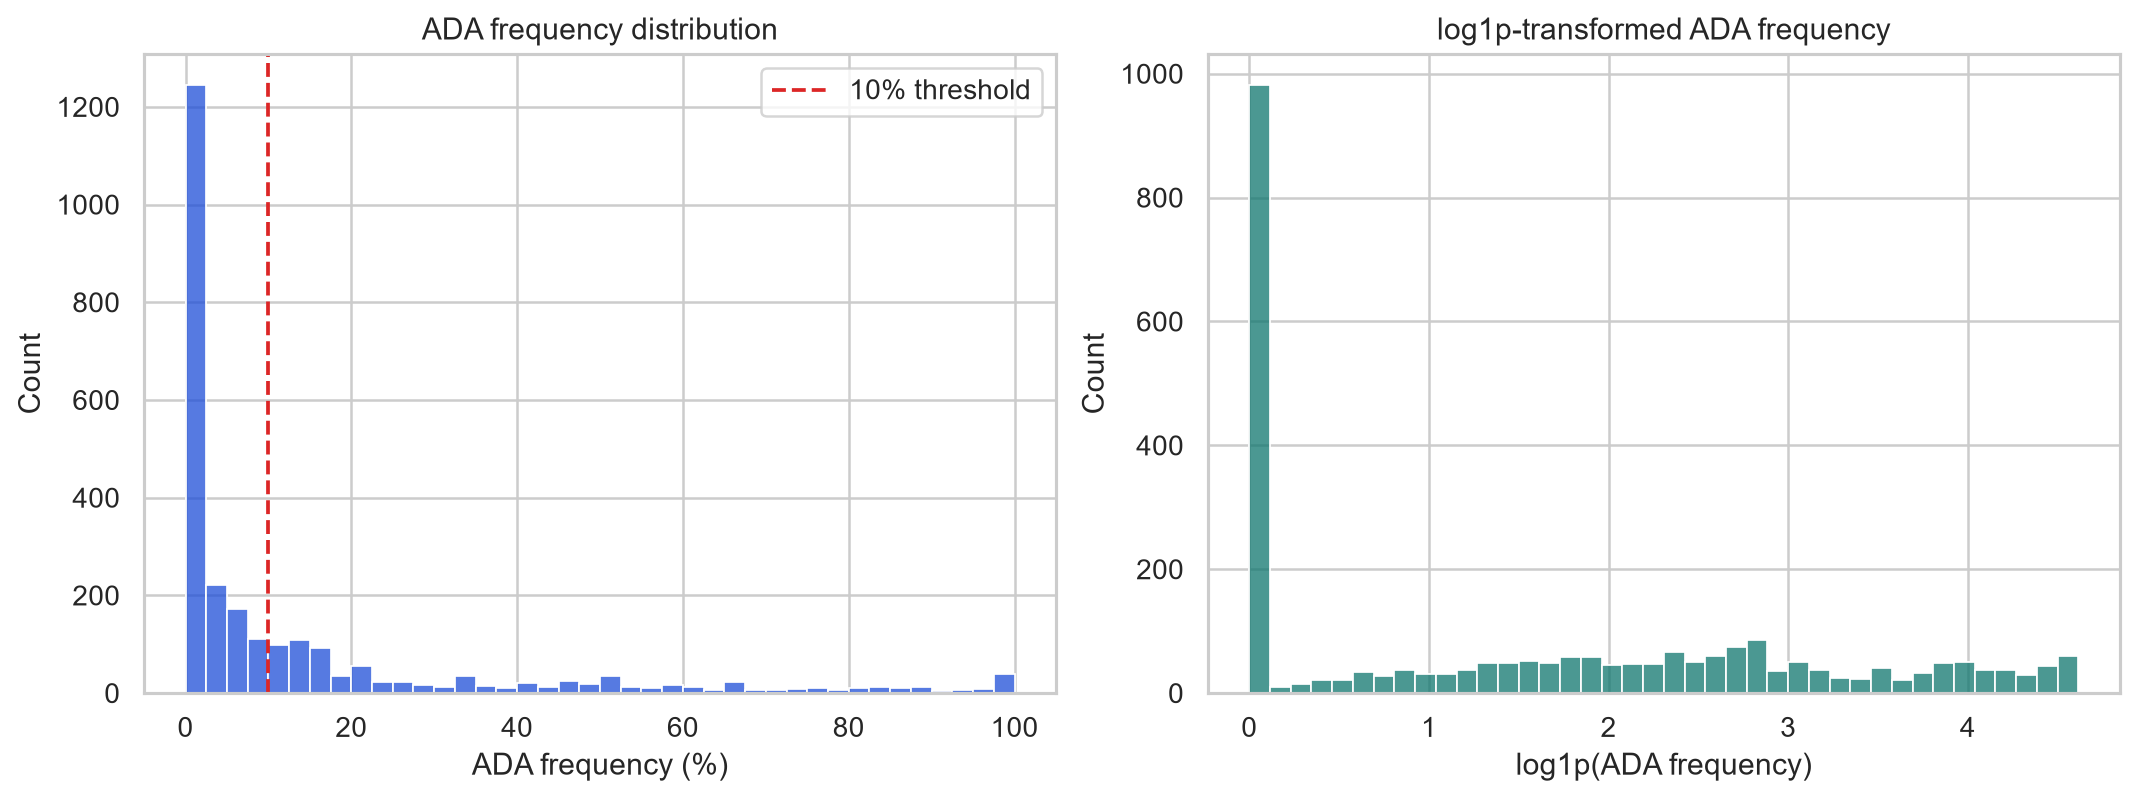

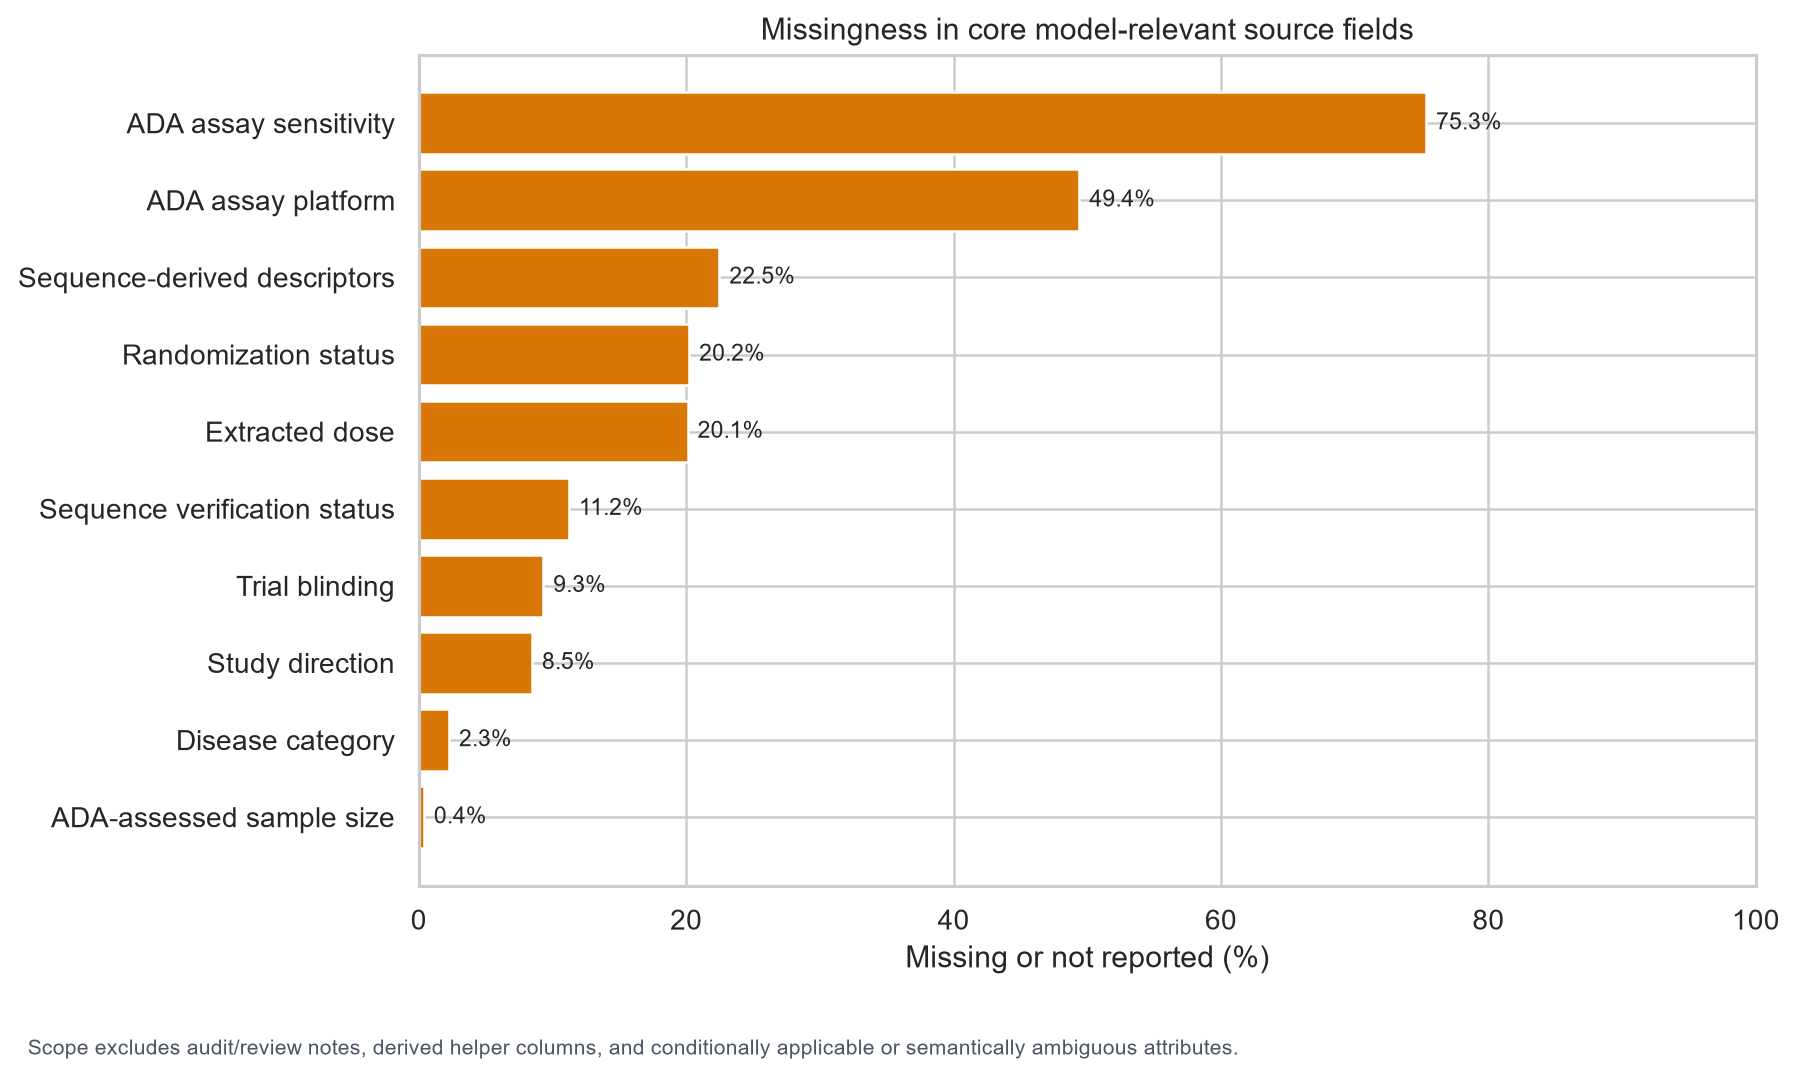

In [4]:
profile = pd.read_csv(ARTIFACTS / "profile.csv")
model_input_missingness = pd.read_csv(ARTIFACTS / "model_input_missingness.csv")
target_summary = pd.read_csv(ARTIFACTS / "target_summary.csv")
moa_summary = pd.read_csv(ARTIFACTS / "moa_summary.csv")
print("Model-input missingness audit (full-column profile remains available separately):")
display(model_input_missingness)
display(target_summary.head(10))
display(moa_summary.head(10))
display(Image(filename=str(FIGURES / "01_ada_distribution.png")))
display(Image(filename=str(FIGURES / "02_missingness.png")))

## 步骤 4：特征工程与研究组隔离

数值特征在 Pipeline 内中位数填补并标准化；类别变量在训练折内填补、合并低频水平并独热编码。划分先按ADA频率区间分层，再按 `model_split_group` 隔离。

In [5]:
split_audit = pd.read_csv(ARTIFACTS / "split_audit.csv")
split_summary = pd.DataFrame(results["split_summary"]).T
display(split_summary)
group_overlap = {
    (a, b): len(set(split_audit.loc[split_audit.partition.eq(a), "model_split_group"]) &
                set(split_audit.loc[split_audit.partition.eq(b), "model_split_group"]))
    for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]
}
group_overlap

,rows,groups,high_ada_prevalence,ada_mean,ada_median
train,1864.0,484.0,0.329936,13.664676,3.0
validation,373.0,98.0,0.329759,14.514315,3.1
test,374.0,98.0,0.328877,12.751943,3.1


{('train', 'validation'): 0, ('train', 'test'): 0, ('validation', 'test'): 0}

## 步骤 5：候选模型与开发集分组交叉验证

In [6]:
performance = pd.read_csv(ARTIFACTS / "performance.csv")
selected_models = results["selected_models"]
print("Selected models:", selected_models)
display(performance[performance.outcome.isin(["continuous", "binary"])])

Selected models: {'continuous': 'Random forest', 'binary': 'Random forest', 'binomial_count': 'Binomial GLM'}


,outcome,model,cv_MAE_mean,cv_MAE_sd,cv_RMSE_mean,cv_RMSE_sd,cv_R2_mean,cv_R2_sd,cv_fit_time_mean_seconds,cv_ROC_AUC_mean,...,test_R2,test_ROC_AUC,test_PR_AUC,test_F1,test_Balanced_Accuracy,test_Brier,test_Log_Loss,test_weighted_MAE_pp,test_weighted_Brier,test_weighted_Log_Loss
0,binary,Dummy prior,NaN,NaN,NaN,NaN,NaN,NaN,0.032099,0.500000,...,NaN,0.500000,0.328877,0.000000,0.500000,0.220718,0.633383,NaN,NaN,NaN
1,binary,Histogram gradient boosting,NaN,NaN,NaN,NaN,NaN,NaN,0.600596,0.814383,...,NaN,0.876057,0.806110,0.694981,0.774220,0.137396,0.423085,NaN,NaN,NaN
2,binary,Logistic regression,NaN,NaN,NaN,NaN,NaN,NaN,0.055870,0.751853,...,NaN,0.725019,0.571905,0.539792,0.641774,0.213537,0.607936,NaN,NaN,NaN
3,binary,Random forest,NaN,NaN,NaN,NaN,NaN,NaN,0.786116,0.804618,...,NaN,0.855132,0.767988,0.701299,0.775483,0.158656,0.493628,NaN,NaN,NaN
4,continuous,Dummy median,13.435722,3.321591,25.411798,5.238477,-0.215775,0.053585,0.037560,NaN,...,-0.223440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,continuous,Histogram gradient boosting,12.391395,1.000687,19.113956,1.876636,0.281877,0.153570,0.426073,NaN,...,0.450086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,continuous,Random forest,12.287496,1.103863,19.377996,2.296161,0.270152,0.131554,0.691144,NaN,...,0.461286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,continuous,Ridge,14.683162,1.489765,20.570041,1.794450,0.161759,0.199277,0.046868,NaN,...,0.359517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 步骤 6：独立测试集评价

In [7]:
selected_performance = performance[performance["selected"].fillna(False)].copy()
display(selected_performance)
predictions = pd.read_csv(ARTIFACTS / "predictions.csv")
display(predictions.head(10))

,outcome,model,cv_MAE_mean,cv_MAE_sd,cv_RMSE_mean,cv_RMSE_sd,cv_R2_mean,cv_R2_sd,cv_fit_time_mean_seconds,cv_ROC_AUC_mean,...,test_R2,test_ROC_AUC,test_PR_AUC,test_F1,test_Balanced_Accuracy,test_Brier,test_Log_Loss,test_weighted_MAE_pp,test_weighted_Brier,test_weighted_Log_Loss
3,binary,Random forest,NaN,NaN,NaN,NaN,NaN,NaN,0.786116,0.804618,...,NaN,0.855132,0.767988,0.701299,0.775483,0.158656,0.493628,NaN,NaN,NaN
6,continuous,Random forest,12.287496,1.103863,19.377996,2.296161,0.270152,0.131554,0.691144,NaN,...,0.461286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,binomial_count,Binomial GLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.261079,0.020227,0.375729


,idc_row_id,model_split_group,molecule_inn_name,ada_frequency_percent_actual,ada_frequency_percent_predicted,ada_high_10_actual,ada_high_10_probability
0,CT0004_A1_001,CT0004,Alemtuzumab,0.000000,9.329494,0,0.364022
1,CT0004_A1_002,CT0004,Alemtuzumab,20.000000,8.838302,1,0.409309
2,CT0029_A1_001,CT0029,Atezolizumab,2.507837,21.538284,0,0.812099
3,CT0029_A1_002,CT0029,Atezolizumab,27.586207,21.538284,1,0.815432
4,CT0029_A1_003,CT0029,Atezolizumab,0.821018,21.538284,0,0.815432
5,CT0032_A1_002,CT0032,Trastuzumab emtansine,7.500000,4.937022,0,0.391789
6,CT0032_A1_003,CT0032,Trastuzumab emtansine,11.700000,4.937022,1,0.391789
7,CT0032_A1_004,CT0032,Trastuzumab emtansine,13.100000,4.937022,1,0.391789
8,CT0035_A2_001,CT0035,Lebrikizumab,16.100000,15.290904,1,0.692147
9,CT0035_A3_001,CT0035,Lebrikizumab,14.000000,12.968730,1,0.663710


## 步骤 7：Feature Importance 与 SHAP

Permutation importance 在隔离测试集上计算；稳定性结果来自5折 GroupKFold。SHAP使用随机森林解释模型并聚合回原始特征。重要性代表预测贡献，不代表因果作用。

,outcome,method,feature,importance_mean,importance_sd,rank,importance_sd_across_folds,positive_fold_fraction,mean_abs_shap
0,continuous,held-out permutation importance,therapeutic_comparator,1.575588,0.288688,1,NaN,NaN,NaN
1,continuous,held-out permutation importance,labelled_as_biosimilar,1.321730,0.212574,2,NaN,NaN,NaN
2,continuous,held-out permutation importance,route_clean,1.004929,0.264989,3,NaN,NaN,NaN
3,continuous,held-out permutation importance,antibody_backbone_clean,0.921471,0.048785,4,NaN,NaN,NaN
4,continuous,held-out permutation importance,target_group,0.645742,0.128878,5,NaN,NaN,NaN
5,continuous,held-out permutation importance,log_assessment_days,0.511214,0.093842,6,NaN,NaN,NaN
6,continuous,held-out permutation importance,log_n_ada_assessed,0.411562,0.140210,7,NaN,NaN,NaN
7,continuous,held-out permutation importance,protein_modality,0.357552,0.038164,8,NaN,NaN,NaN
8,continuous,held-out permutation importance,log_dose_mg_extracted,0.299268,0.057849,9,NaN,NaN,NaN
9,continuous,held-out permutation importance,ada_assay_platform,0.257340,0.074165,10,NaN,NaN,NaN


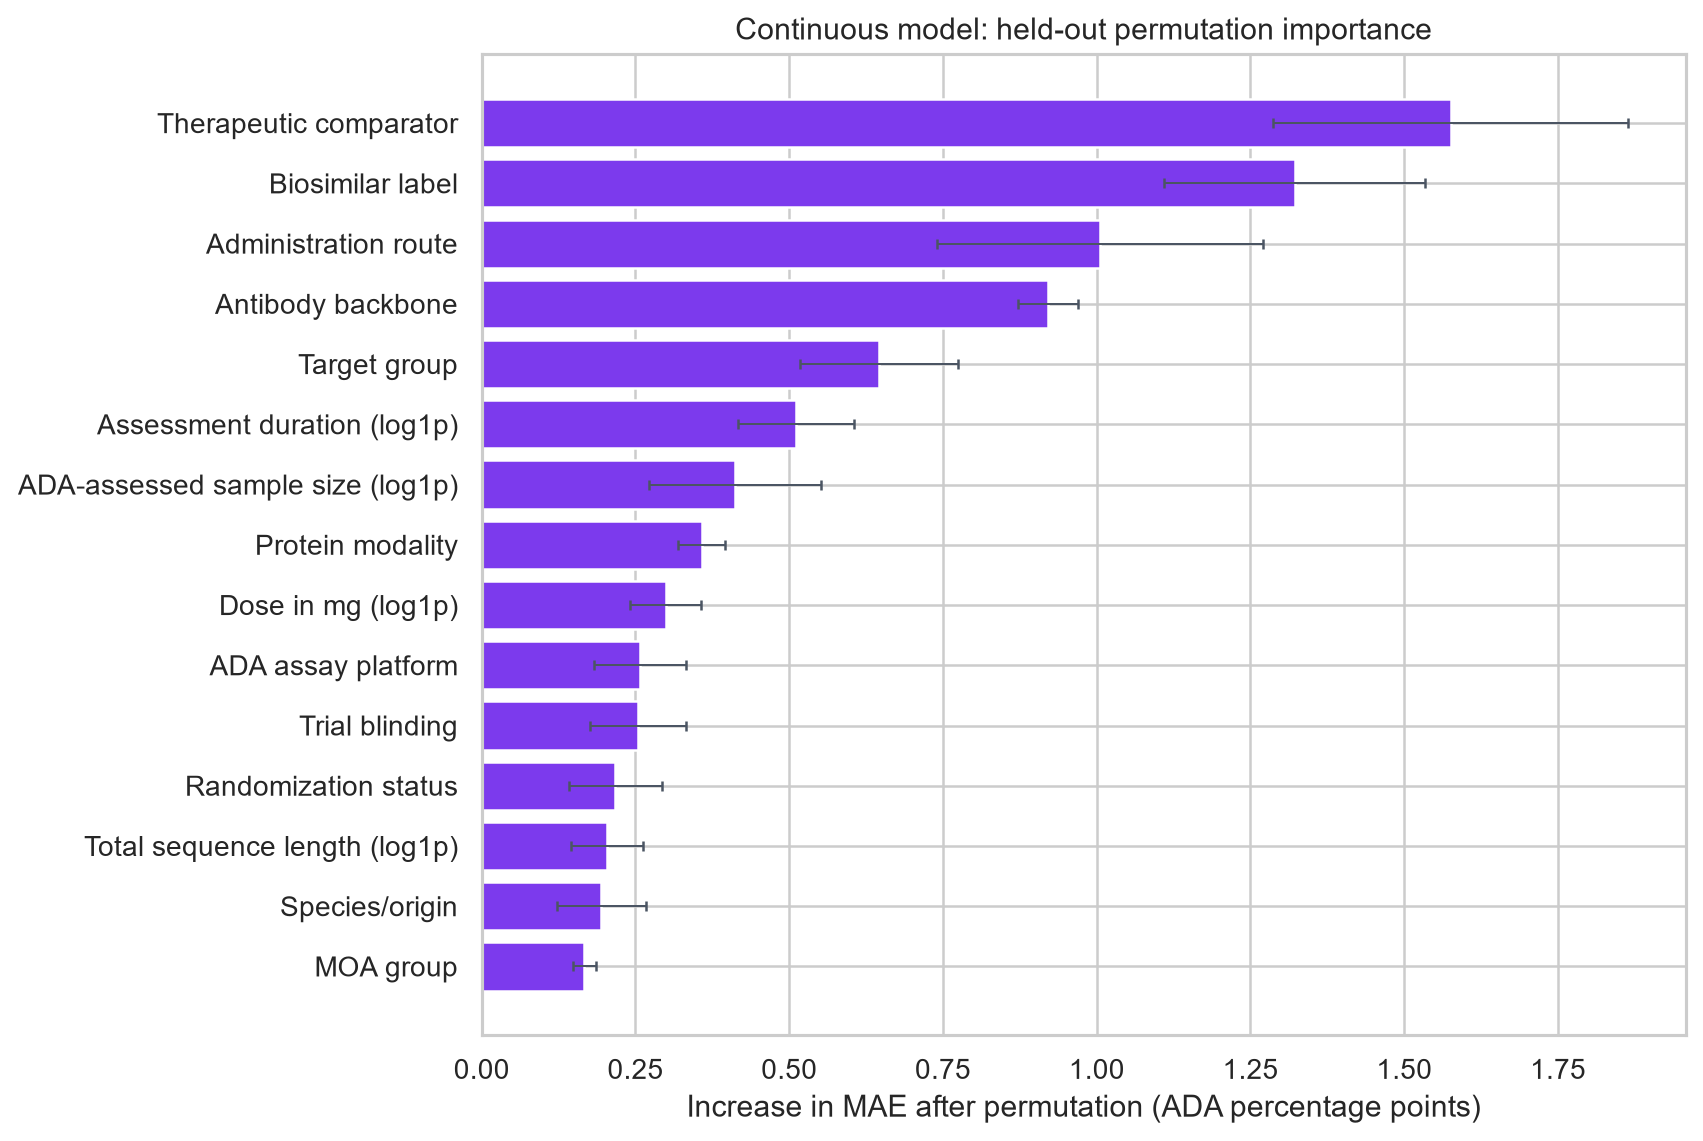

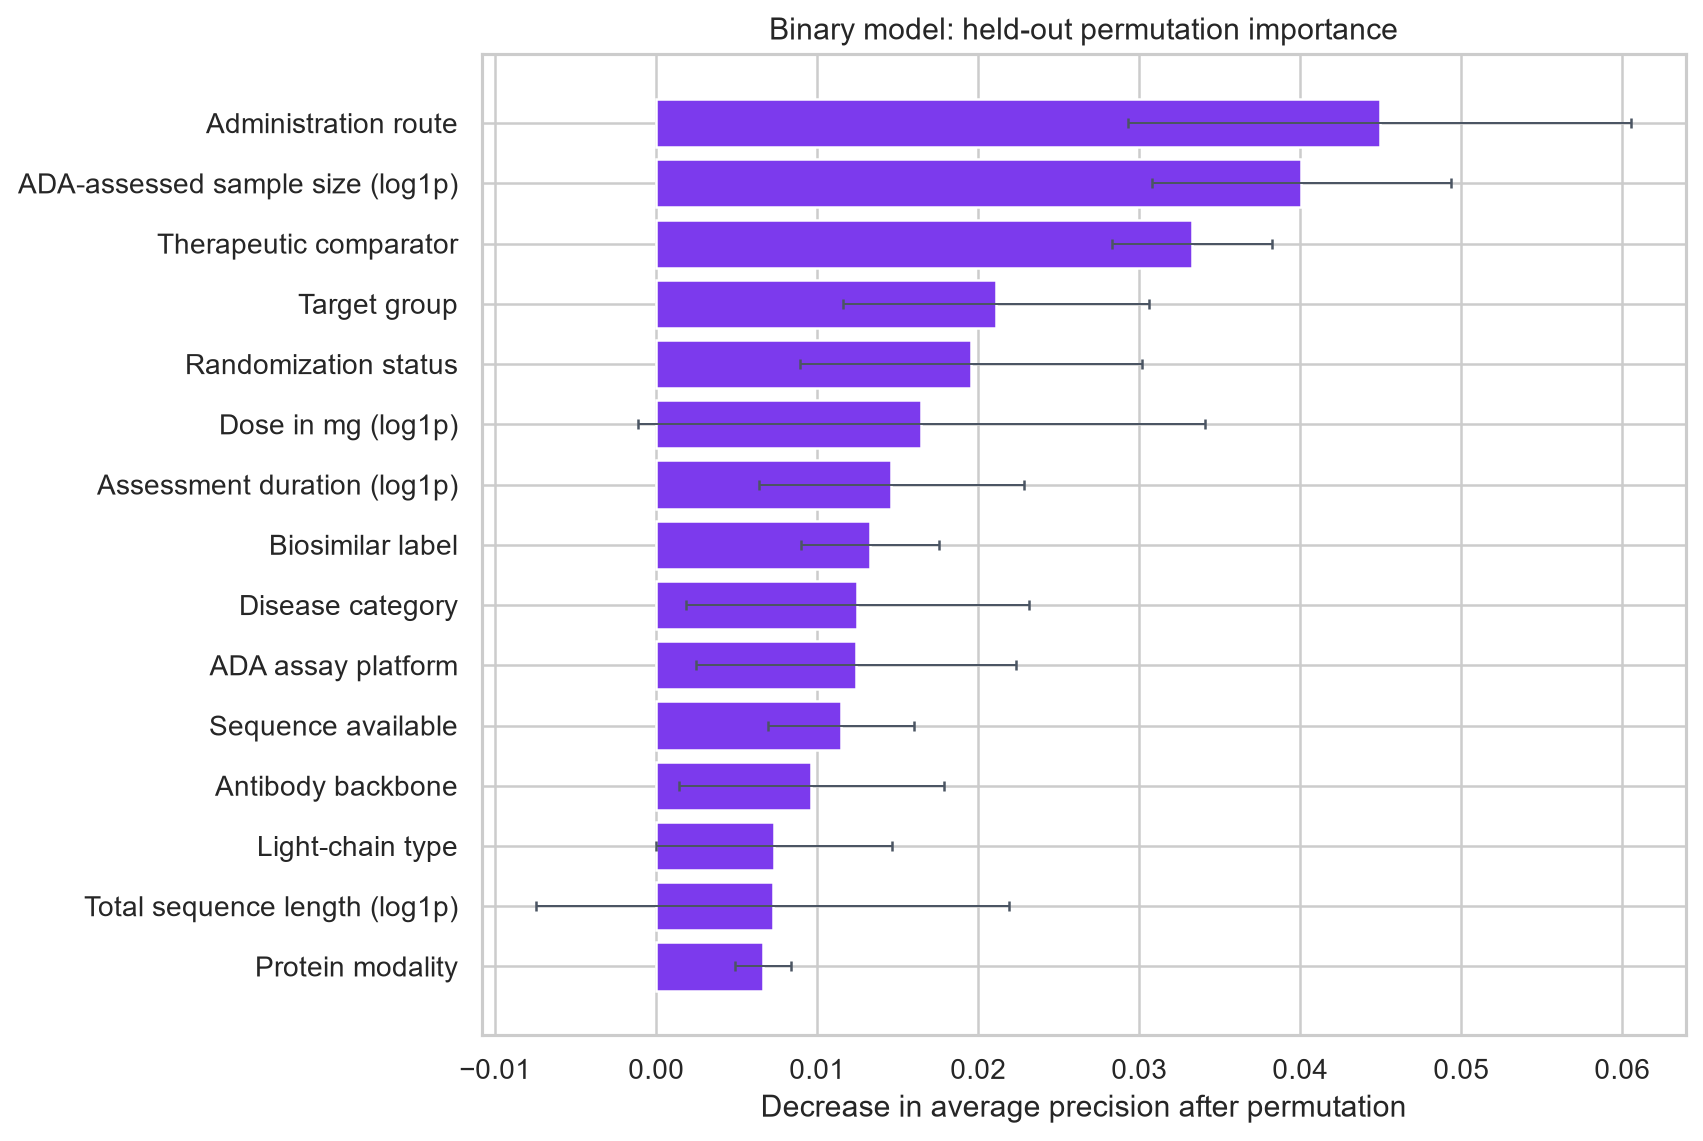

In [8]:
importance = pd.read_csv(ARTIFACTS / "feature_importance.csv")
held_out = importance[importance.method.eq("held-out permutation importance")]
display(held_out.groupby("outcome", group_keys=False).head(15))
display(Image(filename=str(FIGURES / "05_continuous_permutation_importance.png")))
display(Image(filename=str(FIGURES / "06_binary_permutation_importance.png")))

,outcome,method,feature,importance_mean,importance_sd,rank,importance_sd_across_folds,positive_fold_fraction,mean_abs_shap
116,continuous,Random-forest SHAP (aggregated to raw feature),route_clean,NaN,NaN,1,NaN,NaN,3.640991
117,continuous,Random-forest SHAP (aggregated to raw feature),therapeutic_comparator,NaN,NaN,2,NaN,NaN,3.373431
118,continuous,Random-forest SHAP (aggregated to raw feature),target_group,NaN,NaN,3,NaN,NaN,2.975288
119,continuous,Random-forest SHAP (aggregated to raw feature),labelled_as_biosimilar,NaN,NaN,4,NaN,NaN,2.640601
120,continuous,Random-forest SHAP (aggregated to raw feature),disease_category_clean,NaN,NaN,5,NaN,NaN,2.057351
121,continuous,Random-forest SHAP (aggregated to raw feature),species,NaN,NaN,6,NaN,NaN,1.450642
122,continuous,Random-forest SHAP (aggregated to raw feature),trial_blinding,NaN,NaN,7,NaN,NaN,1.135802
123,continuous,Random-forest SHAP (aggregated to raw feature),antibody_backbone_clean,NaN,NaN,8,NaN,NaN,1.082641
124,continuous,Random-forest SHAP (aggregated to raw feature),log_dose_mg_extracted,NaN,NaN,9,NaN,NaN,1.003428
125,continuous,Random-forest SHAP (aggregated to raw feature),log_assessment_days,NaN,NaN,10,NaN,NaN,0.950898


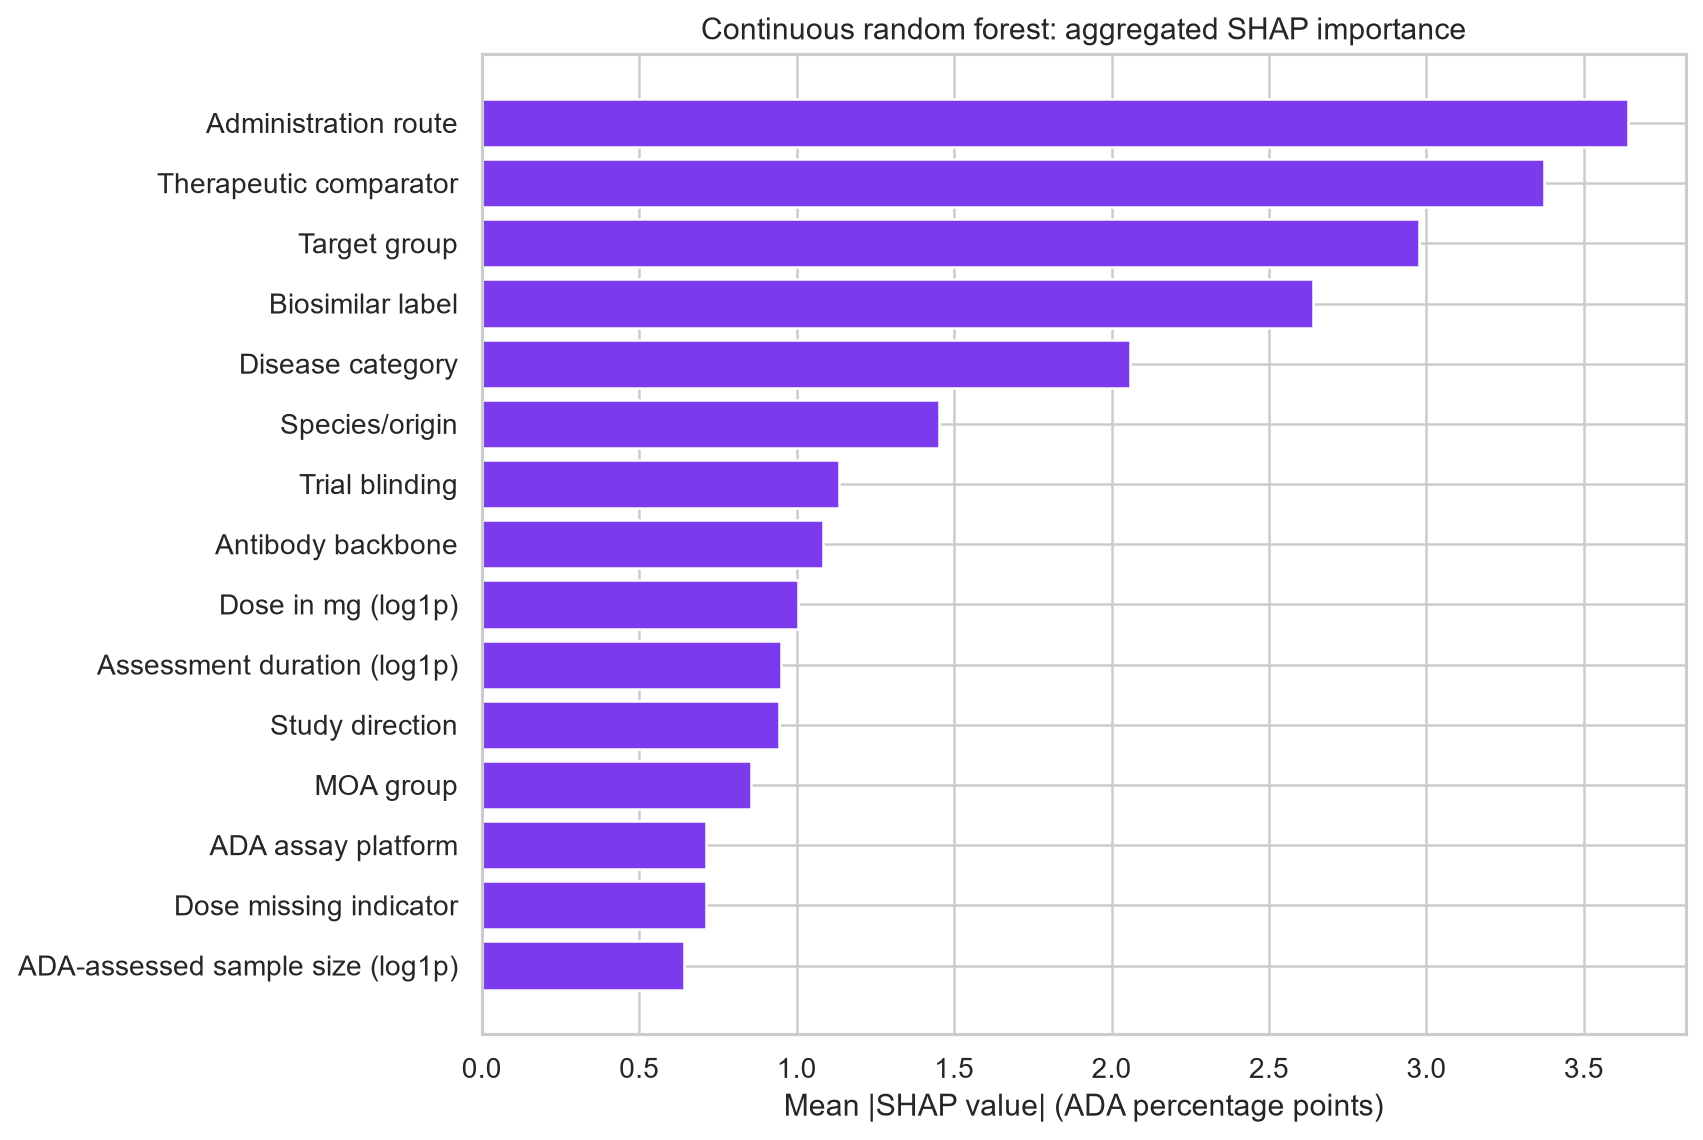

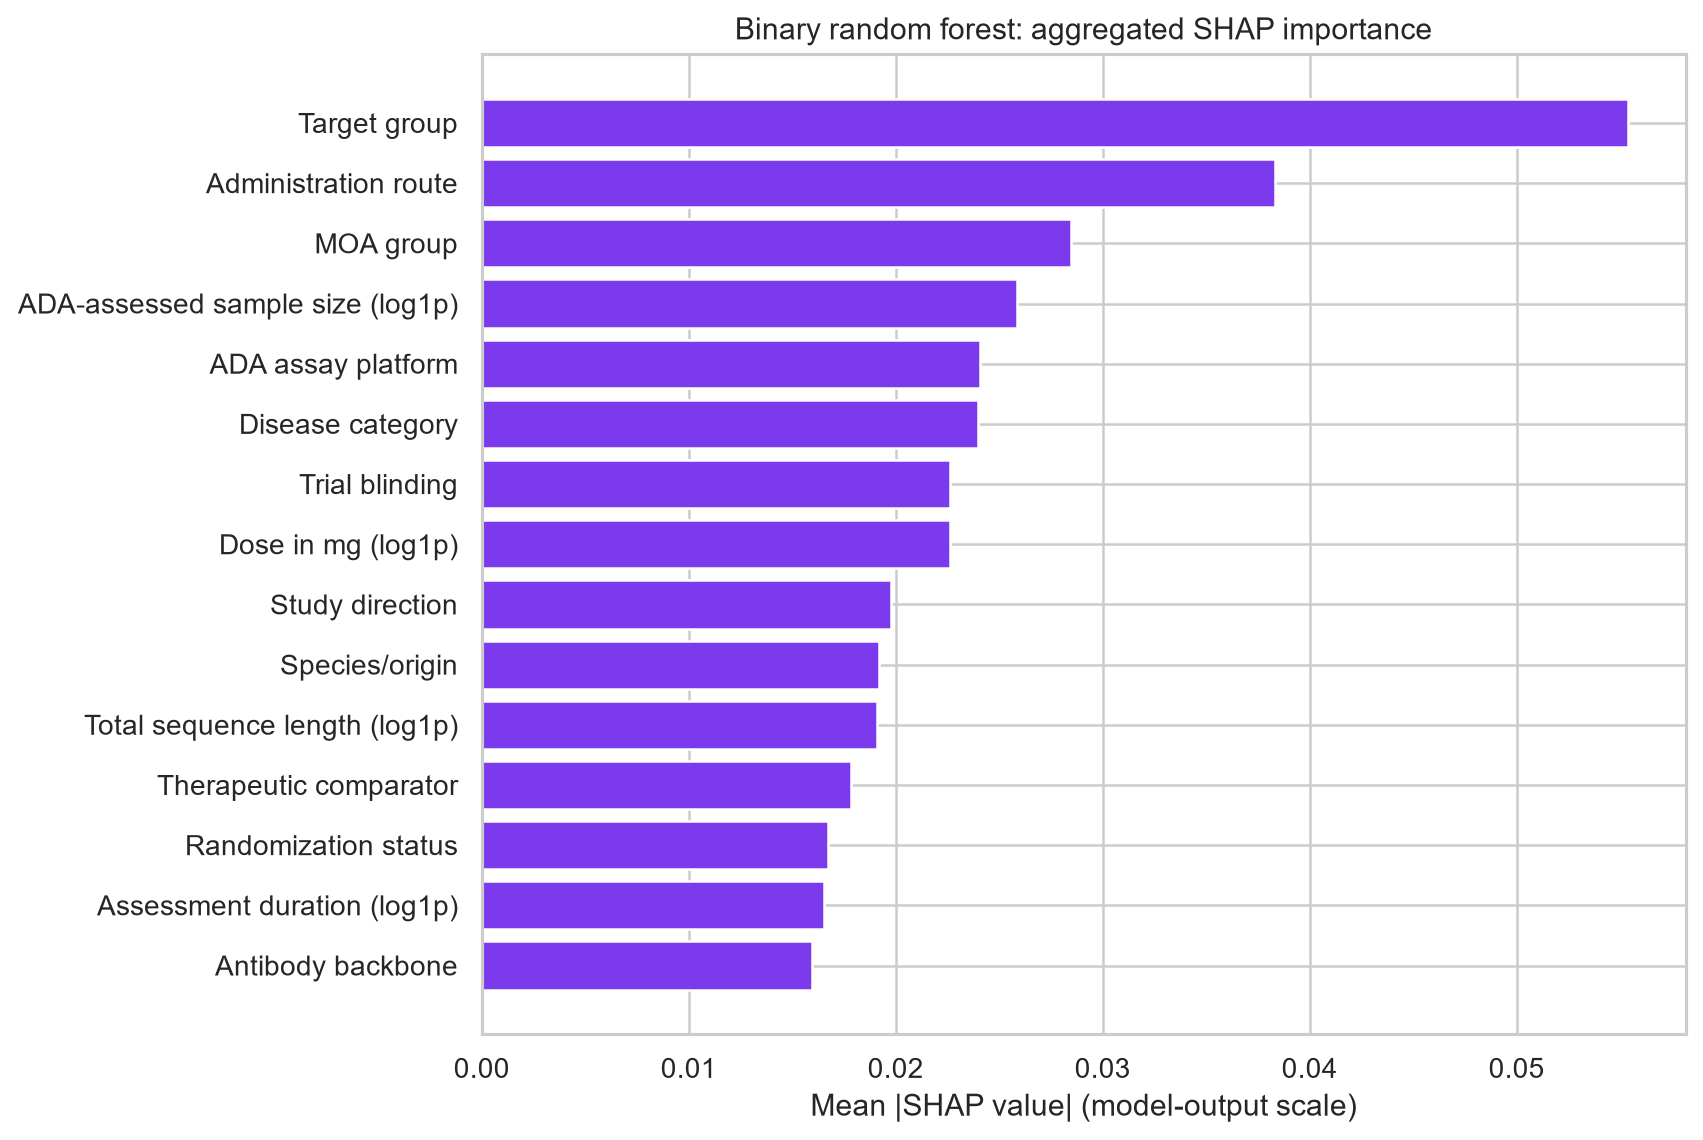

In [9]:
shap_rows = importance[importance.method.str.contains("SHAP", na=False)]
display(shap_rows.groupby("outcome", group_keys=False).head(15))
display(Image(filename=str(FIGURES / "07_continuous_shap_importance.png")))
display(Image(filename=str(FIGURES / "08_binary_shap_importance.png")))

## 步骤 8：二项计数模型

In [10]:
display(performance[performance.outcome.eq("binomial_count")])
pd.Series(results["count_model"], name="value").to_frame()

,outcome,model,cv_MAE_mean,cv_MAE_sd,cv_RMSE_mean,cv_RMSE_sd,cv_R2_mean,cv_R2_sd,cv_fit_time_mean_seconds,cv_ROC_AUC_mean,...,test_R2,test_ROC_AUC,test_PR_AUC,test_F1,test_Balanced_Accuracy,test_Brier,test_Log_Loss,test_weighted_MAE_pp,test_weighted_Brier,test_weighted_Log_Loss
8,binomial_count,Weighted null proportion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.086701,0.033158,0.407402
9,binomial_count,Binomial GLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.261079,0.020227,0.375729


,value
fit_method,L2-regularized GLM fallback
development_rows,2136
test_rows,370
development_total_assessed,241970
test_total_assessed,48896
transformed_feature_count,92


## 步骤 9：敏感性与泛化分析

包括排除计数不一致记录、排除依赖记录、加入分子身份以及未见分子留出。未见分子表现是判断外推能力的关键限制。

In [11]:
sensitivity = pd.read_csv(ARTIFACTS / "sensitivity.csv")
display(sensitivity)

,scenario,outcome,model,development_rows,test_rows,MAE,RMSE,R2,importance_rank_spearman,ROC_AUC,PR_AUC,F1,Balanced_Accuracy,Brier,Log_Loss,test_molecules
0,Exclude count-frequency mismatch,continuous,Random forest,2146,370,10.634224,15.325549,0.453211,0.987685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Exclude count-frequency mismatch,binary,Random forest,2146,370,NaN,NaN,NaN,0.793103,0.868783,0.769352,0.730435,0.794905,0.155764,0.488176,NaN
2,Exclude dependency-flagged rows,continuous,Random forest,2233,374,10.361103,14.861513,0.481075,0.975369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Exclude dependency-flagged rows,binary,Random forest,2233,374,NaN,NaN,NaN,0.911330,0.864477,0.784107,0.729614,0.795728,0.156164,0.488366,NaN
4,Add molecule identity,continuous,Random forest,2237,374,8.347123,12.687095,0.621816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Add molecule identity,binary,Random forest,2237,374,NaN,NaN,NaN,NaN,0.870210,0.775984,0.714894,0.785687,0.152936,0.479926,NaN
6,Unseen-molecule holdout,continuous,Random forest,2172,439,13.324956,22.543930,-0.009831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0
7,Unseen-molecule holdout,binary,Random forest,2172,439,NaN,NaN,NaN,NaN,0.629226,0.397745,0.379630,0.606001,0.202267,0.591640,22.0


## 步骤 10：结论与完整重跑

- 研究组隔离测试用于评估已观察药物空间内的泛化。
- 未见分子测试明显更难，因此不能把当前模型直接视为新分子ADA风险的可靠外部预测器。
- Feature importance用于预测解释，不证明因果关系。
- 二项模型只使用计数一致记录，并以评估人数作为权重。

In [12]:
RUN_FULL_PIPELINE = False
if RUN_FULL_PIPELINE:
    import importlib.util
    module_path = ROOT / "outputs" / "IDC_modeling_pipeline.py"
    spec = importlib.util.spec_from_file_location("idc_modeling_pipeline", module_path)
    pipeline = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(pipeline)
    pipeline.run_pipeline()
else:
    print("Set RUN_FULL_PIPELINE = True to regenerate all model results.")

Set RUN_FULL_PIPELINE = True to regenerate all model results.
